# Project 3 - Exploratory Data Analysis (EDA)

Notebook ini melakukan analisis eksploratif pada dataset `PolyAI/minds14` (subset `en-US`) untuk memahami struktur data, audio, teks, dan intensi sebagai fondasi pipeline ASR dan Klasifikasi Intensi.

## Inisialisasi & Impor Library

In [2]:
import sys
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from wordcloud import WordCloud
from IPython.display import display

In [3]:
# --- Pengaturan Path untuk Impor 'src' ---

# 1. Tentukan path ke folder 'src'
# (Asumsi notebook ini ada di dalam folder 'notebooks/')
src_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'src')

# 2. Tambahkan path 'src' ke sys.path
if src_path not in sys.path:
    sys.path.append(src_path)

# 3. Impor fungsi 'clean_text'
try:
    from utils_asr import clean_text
    print(f"Fungsi clean_text berhasil diimpor dari: {src_path}")
except ImportError:
    print(f"Error: Tidak dapat menemukan utils_asr.py di {src_path}")
    # Definisikan fungsi fallback jika impor gagal agar notebook tetap berjalan
    import re
    def clean_text(text):
        if not isinstance(text, str): return ""
        text = text.lower()
        text = re.sub(r"[^a-z ]", "", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

Fungsi clean_text berhasil diimpor dari: f:\GitHub\Voice-Recognition\src


## 1. Analisis Struktur Data

### 1.1 Memuat Dataset (Loading)

In [5]:
# Memuat dataset `PolyAI/minds14` dengan subset `en-US`.

minds_dataset = load_dataset("PolyAI/minds14", "en-US")
print(minds_dataset)

DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 563
    })
})


### 1.2 Inspeksi Sampel Data

In [6]:
# Melihat satu sampel data untuk memahami fitur-fitur yang tersedia, terutama `audio` (array & sampling rate) dan `transcription`.

sample = minds_dataset['train'][0]
display(sample)
print(f"Sampling Rate Asli: {sample['audio']['sampling_rate']} Hz")

{'path': 'en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav',
 'audio': {'path': '602ba55abb1e6d0fbce92065.wav',
  'array': array([ 0.        ,  0.00024414, -0.00024414, ..., -0.00024414,
          0.        ,  0.        ]),
  'sampling_rate': 8000},
 'transcription': 'I would like to set up a joint account with my partner',
 'english_transcription': 'I would like to set up a joint account with my partner',
 'intent_class': 11,
 'lang_id': 4}

Sampling Rate Asli: 8000 Hz


## 2. Analisis Fitur Audio

### 2.1 Menghitung & Visualisasi Durasi Audio

Map: 100%|██████████| 563/563 [00:27<00:00, 20.72 examples/s]  


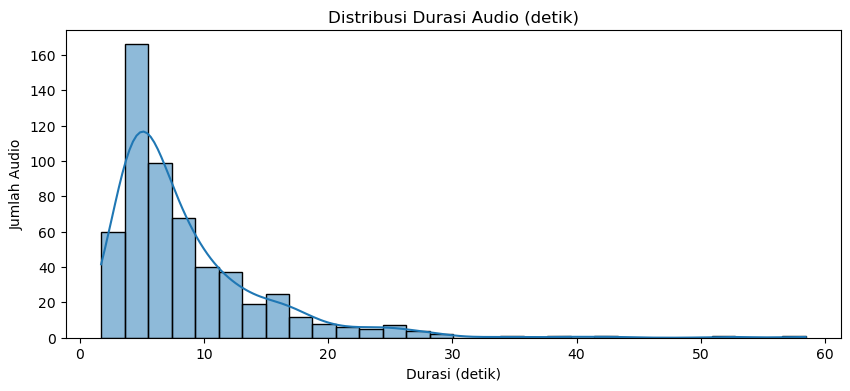


Statistik Durasi Audio:
count    563.000000
mean       8.577396
std        6.390572
min        1.706625
25%        4.437375
50%        6.400000
75%       10.410687
max       58.453375
Name: duration, dtype: float64


In [7]:
# Menganalisis distribusi durasi audio untuk mengidentifikasi outlier atau masalah pada data.

# Ambil 'train' split
dataset = minds_dataset['train']

# Fungsi untuk menghitung durasi
def compute_duration(sample):
    if sample['audio']['array'] is None:
        return {"duration": 0.0}
    duration_sec = len(sample['audio']['array']) / sample['audio']['sampling_rate']
    return {"duration": duration_sec}

# Buat kolom 'duration'
dataset_with_duration = dataset.map(compute_duration)

# Ubah ke Pandas DataFrame untuk plotting
df = pd.DataFrame(dataset_with_duration)

# Plotting Distribusi Durasi
plt.figure(figsize=(10, 4))
sns.histplot(df['duration'], bins=30, kde=True)
plt.title('Distribusi Durasi Audio (detik)')
plt.xlabel('Durasi (detik)')
plt.ylabel('Jumlah Audio')
plt.show()

# Tampilkan statistik deskriptif
print("\nStatistik Durasi Audio:")
print(df['duration'].describe())

### 2.2 Visualisasi Representasi Audio (Fitur Model)

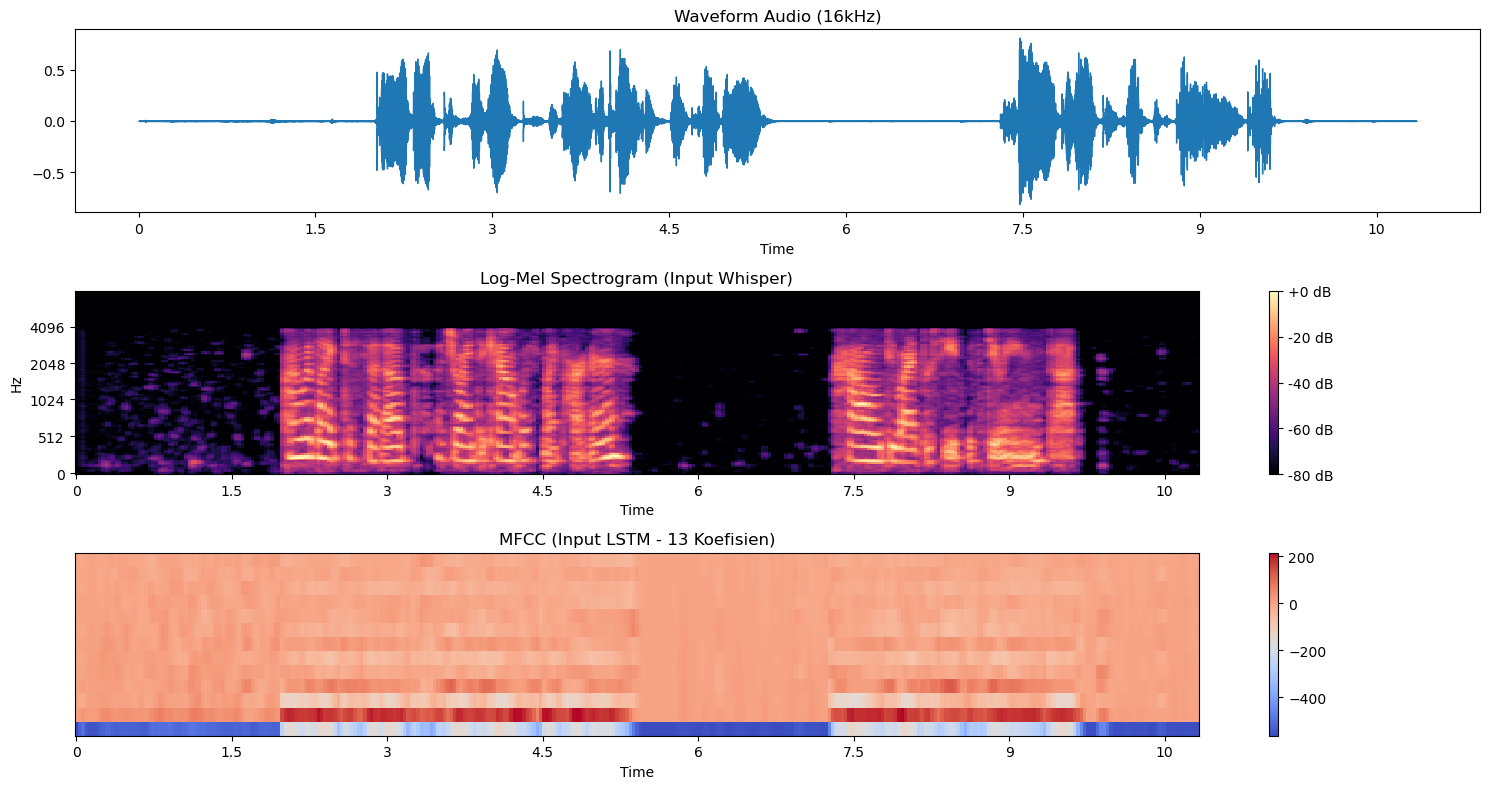

In [ ]:
# Memvisualisasikan 3 representasi audio untuk satu sampel:
# 1.  Waveform: Sinyal mentah.
# 2.  Log-Mel Spectrogram: Input untuk model Whisper.
# 3.  MFCC: Input untuk model LSTM.
# 
# *Catatan: Audio di-resample ke 16kHz, sesuai standar pipeline training.*


# Ambil satu sampel dan resample ke 16kHz
y_16k = librosa.resample(y=np.array(sample['audio']['array']), 
                        orig_sr=sample['audio']['sampling_rate'], 
                        target_sr=16000)
sr_16k = 16000

# 1. Plot Waveform
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
librosa.display.waveshow(y_16k, sr=sr_16k)
plt.title('Waveform Audio (16kHz)')

# 2. Plot Log-Mel Spectrogram (Input untuk Whisper)
S = librosa.feature.melspectrogram(y=y_16k, sr=sr_16k, n_mels=128)
log_S = librosa.power_to_db(S, ref=np.max)
plt.subplot(3, 1, 2)
librosa.display.specshow(log_S, sr=sr_16k, x_axis='time', y_axis='mel')
plt.title('Log-Mel Spectrogram (Input Whisper)')
plt.colorbar(format='%+2.0f dB')

# 3. Plot MFCC (Input untuk LSTM)
mfcc = librosa.feature.mfcc(y=y_16k, sr=sr_16k, n_mfcc=13)
plt.subplot(3, 1, 3)
librosa.display.specshow(mfcc, sr=sr_16k, x_axis='time')
plt.title('MFCC (Input LSTM - 13 Koefisien)')
plt.colorbar()

plt.tight_layout()
plt.show()

## 3. Analisis Fitur Teks (Transkripsi)

### 3.1 Distribusi Panjang Teks (Kata)

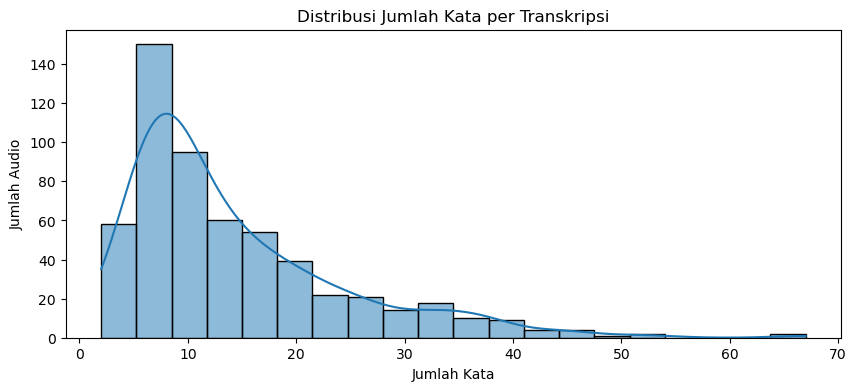


Statistik Jumlah Kata:
count    563.000000
mean      14.362345
std       10.169741
min        2.000000
25%        7.000000
50%       11.000000
75%       19.000000
max       67.000000
Name: num_words, dtype: float64


In [9]:
# Menganalisis jumlah kata per transkripsi untuk memahami kompleksitas bahasa.

# Hitung jumlah kata
df['num_words'] = df['transcription'].apply(lambda x: len(x.split()))

# Plot distribusi
plt.figure(figsize=(10, 4))
sns.histplot(df['num_words'], bins=20, kde=True) 
plt.title('Distribusi Jumlah Kata per Transkripsi')
plt.xlabel('Jumlah Kata')
plt.ylabel('Jumlah Audio')
plt.show()

# Tampilkan statistik
print("\nStatistik Jumlah Kata:")
print(df['num_words'].describe())

### 3.2 Analisis Vocabulary (Teks Asli vs Bersih)

Jumlah karakter unik (Asli): 41
Karakter unik (Asli): [' ', '$', "'", '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Jumlah karakter unik (Bersih): 27
Karakter unik (Bersih): [' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


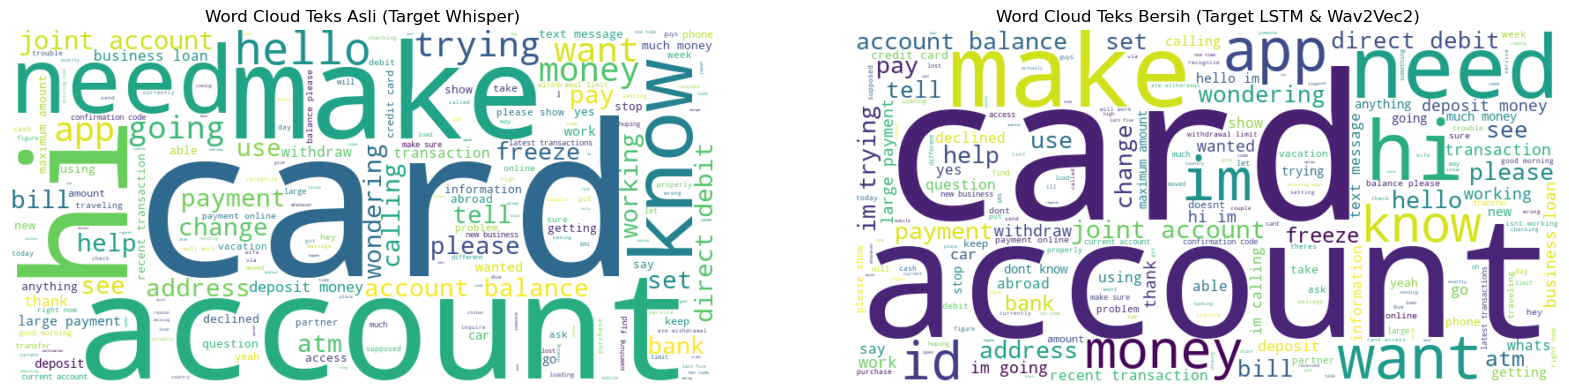

In [10]:
# Menganalisis karakter unik dalam transkripsi asli dan membandingkannya dengan transkripsi yang sudah dibersihkan. Ini membenarkan *pipeline preprocessing* yang berbeda untuk CTC (LSTM/Wav2Vec2) vs Seq2Seq (Whisper).

# 1. Analisis Vocabulary Asli
all_text_original = " ".join(df['transcription'].str.lower())
unique_chars_original = sorted(list(set(all_text_original)))
print(f"Jumlah karakter unik (Asli): {len(unique_chars_original)}")
print(f"Karakter unik (Asli): {unique_chars_original}")

# 2. Terapkan fungsi clean_text
df['cleaned_transcription'] = df['transcription'].apply(clean_text)
all_text_cleaned = " ".join(df['cleaned_transcription'])
unique_chars_cleaned = sorted(list(set(all_text_cleaned)))
print(f"\nJumlah karakter unik (Bersih): {len(unique_chars_cleaned)}")
print(f"Karakter unik (Bersih): {unique_chars_cleaned}")

# 3. Visualisasi Word Cloud
wc_original = WordCloud(width=800, height=400, background_color='white').generate(all_text_original)
wc_cleaned = WordCloud(width=800, height=400, background_color='white').generate(all_text_cleaned)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(wc_original, interpolation='bilinear')
ax1.set_title('Word Cloud Teks Asli (Target Whisper)')
ax1.axis('off')

ax2.imshow(wc_cleaned, interpolation='bilinear')
ax2.set_title('Word Cloud Teks Bersih (Target LSTM & Wav2Vec2)')
ax2.axis('off')
plt.show()

## 4. Analisis Fitur Target (Klasifikasi Intensi)

Jumlah Intensi (Kelas) Unik: 14

Deskripsi kolom intent_class:
count    563.000000
mean       6.586146
std        3.921964
min        0.000000
25%        3.000000
50%        7.000000
75%       10.000000
max       13.000000
Name: intent_class, dtype: float64


C:\Users\arjun\AppData\Local\Temp\ipykernel_19844\3937253319.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='intent_class', data=df, palette='viridis')


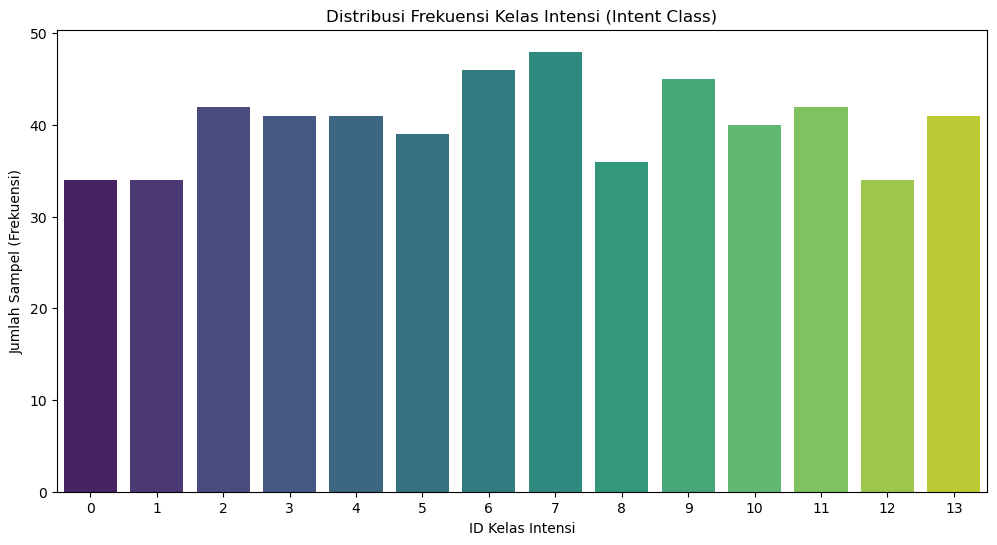


Kesimpulan: Ke-14 kelas intensi terdistribusi SANGAT SEIMBANG.


In [11]:
# Menganalisis kolom `intent_class` untuk *pipeline* kedua kita (Klasifikasi Intensi).

# 1. Analisis Statistik
num_classes = df['intent_class'].nunique()
print(f"Jumlah Intensi (Kelas) Unik: {num_classes}")
print("\nDeskripsi kolom intent_class:")
print(df['intent_class'].describe())

# 2. Visualisasi Distribusi (Class Balance)
plt.figure(figsize=(12, 6))
sns.countplot(x='intent_class', data=df, palette='viridis')
plt.title('Distribusi Frekuensi Kelas Intensi (Intent Class)')
plt.xlabel('ID Kelas Intensi')
plt.ylabel('Jumlah Sampel (Frekuensi)')
plt.show()

print("\nKesimpulan: Ke-14 kelas intensi terdistribusi SANGAT SEIMBANG.")